# Лабораторная 1: выборочные характеристики и распределения

В этой работе строятся 8 выборок из 4 распределений (по 2 объема: 100 и 1000), считаются выборочные характеристики, результаты сравниваются с `numpy`, а затем визуально сравниваются гистограммы и теоретические плотности/функции вероятности.


In [17]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st


## Генерация выборок и как работает `rvs(...)`

Для генерации используется метод `scipy.stats.<distribution>.rvs(...)`:
- `size` задает объем выборки;
- параметры распределения (`loc`, `scale`, `p`, `n`) задают закон распределения;
- `random_state` фиксирует генератор случайных чисел и делает результат воспроизводимым.

В этой работе зафиксировано `GROUP_NUMBER = 12`, поэтому все результаты можно повторить на любой машине при тех же параметрах.


## Параметры функций выборок и обозначения распределений

Ниже указано, как параметры в `scipy.stats.<dist>.rvs(...)` связаны с обозначениями распределений.

### 1) Равномерное распределение
Обозначение: \(X \sim U(a, b)\).

В коде:
- `st.uniform.rvs(loc=2, scale=5, size=n, random_state=12)`
- `a = loc = 2`
- `b = loc + scale = 2 + 5 = 7`
- значит: \(X \sim U(2, 7)\)

### 2) Распределение Бернулли
Обозначение: \(X \sim B(p)\) или \(Bernoulli(p)\).

В коде:
- `st.bernoulli.rvs(p=0.27, size=n, random_state=12)`
- значит: \(X \sim B(0.27)\)

### 3) Биномиальное распределение
Обозначение: \(X \sim Bin(n, p)\).

В коде:
- `st.binom.rvs(n=12, p=0.35, size=n_sample, random_state=12)`
- параметры распределения: `n=12`, `p=0.35`
- значит: \(X \sim Bin(12, 0.35)\)

### 4) Нормальное распределение
Обозначение: \(X \sim N(\mu, \sigma^2)\).

В коде:
- `st.norm.rvs(loc=4.5, scale=1.8, size=n, random_state=12)`
- `\mu = loc = 4.5`, `\sigma = scale = 1.8`
- значит: \(X \sim N(4.5, 1.8^2)\)

Где:
- `size` (или `n`, `n_sample`) — объем выборки (100 или 1000);
- `random_state=12` — фиксирует генерацию случайных чисел для воспроизводимости результатов.


In [18]:
random_state = 16

## Математическое обоснование для выборок

### 1) Равномерное распределение `U(2, 7)` (выборки №1 и №2)
Если `X ~ U(a, b)`, то:
\[
\mathbb{E}[X] = \frac{a+b}{2}, \quad
\mathbb{D}[X] = \frac{(b-a)^2}{12}, \quad
\sigma = \sqrt{\mathbb{D}[X]}.
\]
Для `a=2, b=7`: \(\mathbb{E}[X]=4.5\), \(\mathbb{D}[X]=\frac{25}{12}\approx 2.0833\), \(\sigma\approx1.4434\).

### 2) Распределение Бернулли `B(0.27)` (выборки №3 и №4)
Если `X ~ Bernoulli(p)`, то:
\[
\mathbb{P}(X=1)=p,\; \mathbb{P}(X=0)=1-p,
\]
\[
\mathbb{E}[X]=p, \quad
\mathbb{D}[X]=p(1-p), \quad
\sigma=\sqrt{p(1-p)}.
\]
Для `p=0.27`: \(\mathbb{E}[X]=0.27\), \(\mathbb{D}[X]=0.1971\), \(\sigma\approx0.4440\).

### 3) Биномиальное распределение `Bin(n=12, p=0.35)` (выборки №5 и №6)
Если `X ~ Bin(n, p)`, то:
\[
\mathbb{P}(X=k)=\binom{n}{k}p^k(1-p)^{n-k}, \quad k=0,1,\dots,n,
\]
\[
\mathbb{E}[X]=np, \quad
\mathbb{D}[X]=np(1-p), \quad
\sigma=\sqrt{np(1-p)}.
\]
Для `n=12, p=0.35`: \(\mathbb{E}[X]=4.2\), \(\mathbb{D}[X]=2.73\), \(\sigma\approx1.6523\).

### 4) Нормальное распределение `N(4.5, 1.8^2)` (выборки №7 и №8)
Если `X ~ N(\mu, \sigma^2)`, то:
\[
\mathbb{E}[X]=\mu, \quad \mathbb{D}[X]=\sigma^2.
\]
Для `\mu=4.5, \sigma=1.8`: \(\mathbb{E}[X]=4.5\), \(\mathbb{D}[X]=3.24\), \(\sigma=1.8\).

При увеличении размера выборки с 100 до 1000 оценки обычно становятся ближе к теоретическим значениям (закон больших чисел).


In [19]:
samples = {}

samples.update({
        "uniform_100": st.uniform.rvs(loc=2, scale=5, size=100, random_state=random_state),
        "uniform_1000": st.uniform.rvs(loc=2, scale=5, size=1000, random_state=random_state),
    })
samples.update({
        "bernoulli_100": st.bernoulli.rvs(p=0.27, size=100, random_state=random_state),
        "bernoulli_1000": st.bernoulli.rvs(p=0.27, size=1000, random_state=random_state),
    })
samples.update( {
        "binom_100": st.binom.rvs(n=12, p=0.35, size=100, random_state=random_state),
        "binom_1000": st.binom.rvs(n=12, p=0.35, size=1000, random_state=random_state),
    }

)
samples.update({
        "norm_100": st.norm.rvs(loc=4.5, scale=1.8, size=100, random_state=random_state),
        "norm_1000": st.norm.rvs(loc=4.5, scale=1.8, size=1000, random_state=random_state),
    }

)


## Собственные функции статистик (без `numpy`)

Используются формулы:
\[
\bar{x}=\frac{1}{n}\sum_{i=1}^n x_i, \quad
D=\frac{1}{n}\sum_{i=1}^n(x_i-\bar{x})^2, \quad
s=\sqrt{D}.
\]


In [20]:
def mean(X):
    total = 0.0
    count = 0
    for xi in X:
        total += float(xi)
        count += 1
    return total / count if count else float("nan")


def var(X):
    count = len(X)
    if count == 0:
        return float("nan")

    Xr = mean(X)
    sq_sum = 0.0
    for value in X:
        sq_sum +=  (float(value) - Xr)**2
    return sq_sum / count


def std(X):
    return math.sqrt(var(X))


In [21]:
mean_np = {name: np.mean(sample,) for name, sample in samples.items()}
var_np = {name: np.var(sample, ) for name, sample in samples.items()}
std_np = {name: np.std(sample,) for name, sample in samples.items()}

mean_my = {name: mean(sample,) for name, sample in samples.items()}
var_my = {name: var(sample, ) for name, sample in samples.items()}
std_my = {name: std(sample,) for name, sample in samples.items()}

In [22]:
sample_order = [
    "uniform_100",
    "uniform_1000",
    "bernoulli_100",
    "bernoulli_1000",
    "binom_100",
    "binom_1000",
    "norm_100",
    "norm_1000",
]

table_rows = []
for i, name in enumerate(sample_order, start=1):
    table_rows.append({
        "№ выборки": i,
        "среднее своё": mean_my[name],
        "дисперсия своя": var_my[name],
        "стандартное отклонение своё": std_my[name],
        "среднее numpy": mean_np[name],
        "дисперсия numpy": var_np[name],
        "стандартное отклонение numpy": std_np[name],
    })

result_table = pd.DataFrame(table_rows)
result_table


,№ выборки,среднее своё,дисперсия своя,стандартное отклонение своё,среднее numpy,дисперсия numpy,стандартное отклонение numpy
0,1,4.482376,2.094645,1.447289,4.482376,2.094645,1.447289
1,2,4.450935,2.085030,1.443963,4.450935,2.085030,1.443963
2,3,0.250000,0.187500,0.433013,0.250000,0.187500,0.433013
3,4,0.250000,0.187500,0.433013,0.250000,0.187500,0.433013
4,5,4.190000,2.493900,1.579209,4.190000,2.493900,1.579209
5,6,4.134000,2.740044,1.655308,4.134000,2.740044,1.655308
6,7,4.537930,3.154746,1.776160,4.537930,3.154746,1.776160
7,8,4.462000,3.174096,1.781599,4.462000,3.174096,1.781599


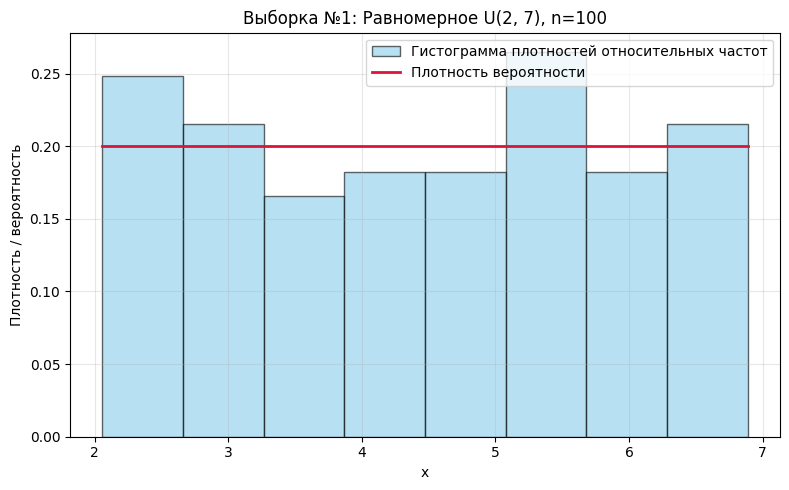

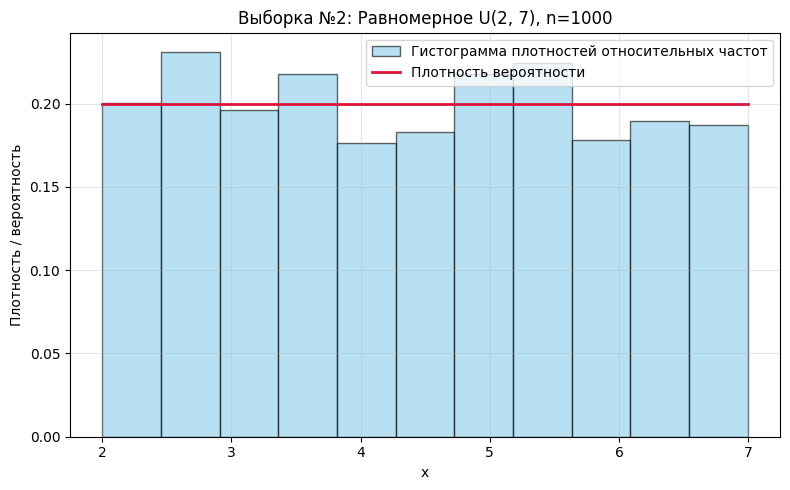

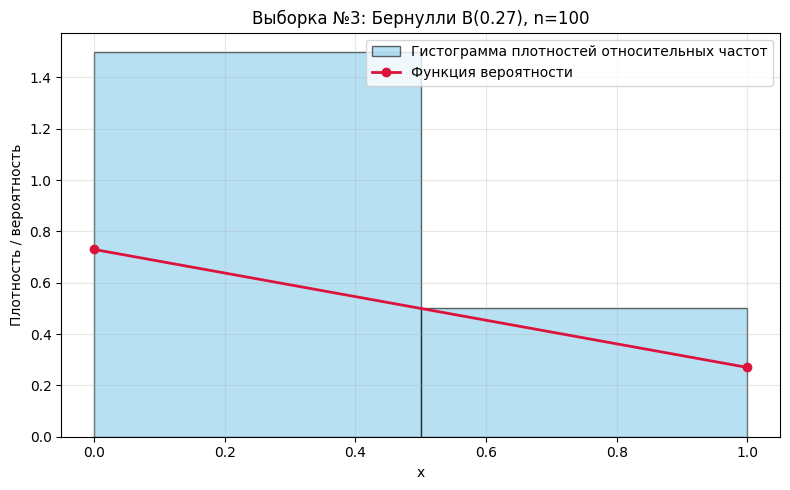

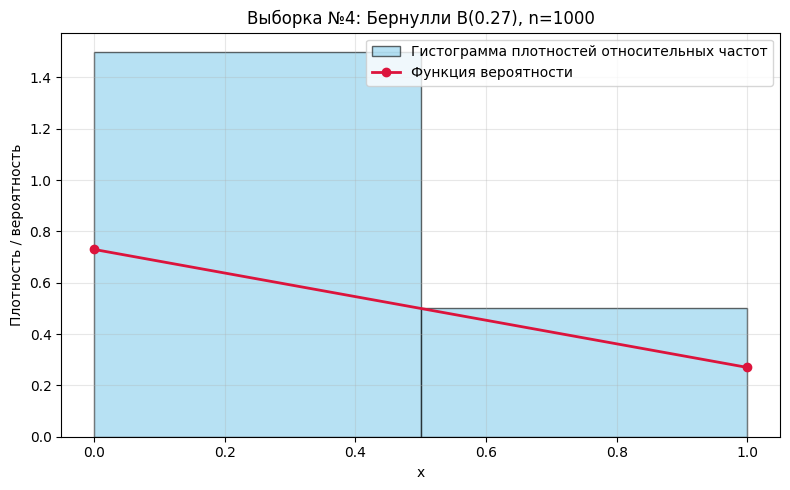

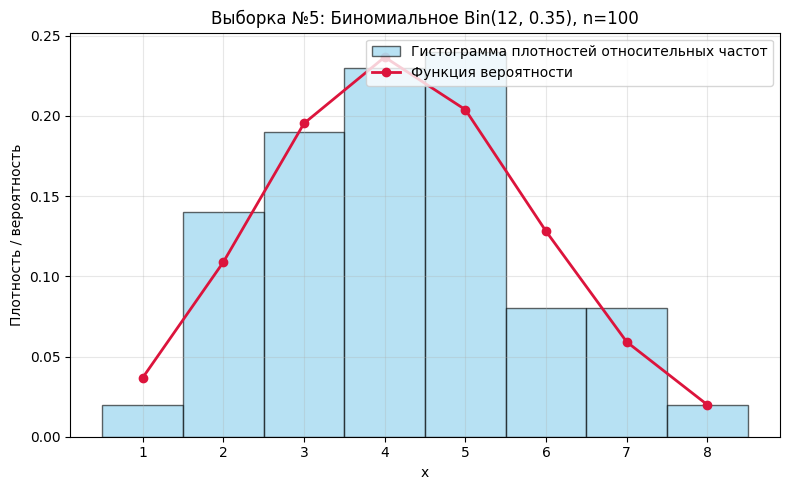

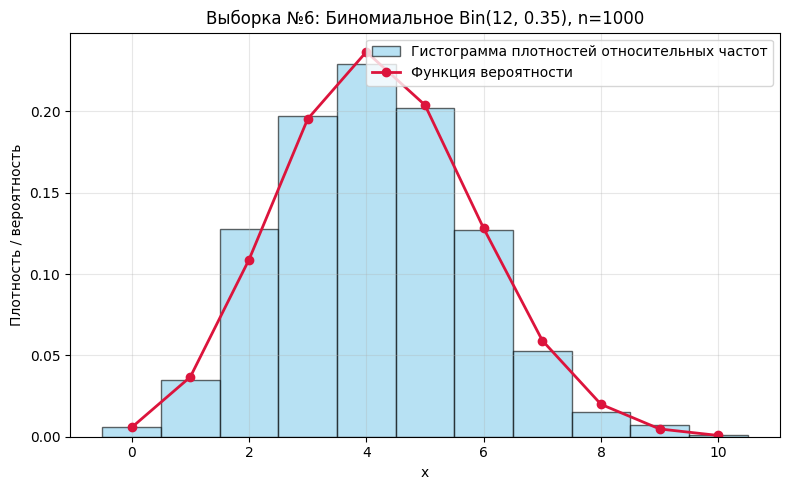

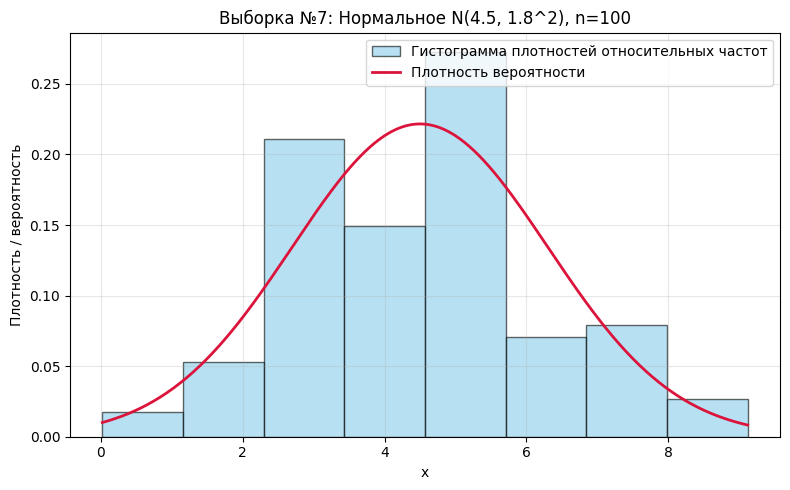

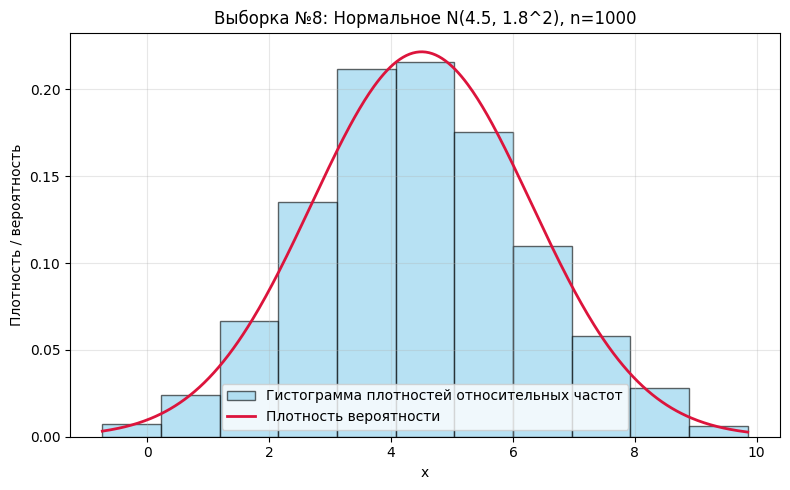

In [23]:
plot_config = [
    (1, "uniform_100", "Равномерное U(2, 7), n=100", "continuous", "uniform"),
    (2, "uniform_1000", "Равномерное U(2, 7), n=1000", "continuous", "uniform"),
    (3, "bernoulli_100", "Бернулли B(0.27), n=100", "discrete", "bernoulli"),
    (4, "bernoulli_1000", "Бернулли B(0.27), n=1000", "discrete", "bernoulli"),
    (5, "binom_100", "Биномиальное Bin(12, 0.35), n=100", "discrete", "binom"),
    (6, "binom_1000", "Биномиальное Bin(12, 0.35), n=1000", "discrete", "binom"),
    (7, "norm_100", "Нормальное N(4.5, 1.8^2), n=100", "continuous", "norm"),
    (8, "norm_1000", "Нормальное N(4.5, 1.8^2), n=1000", "continuous", "norm"),
]

for sample_number, sample_name, title, dist_kind, dist_name in plot_config:
    sample = samples[sample_name]
    plt.figure(figsize=(8, 5))

    if dist_kind == "continuous":
        # Плотность относительных частот (высота столбца гистограммы):
        # h_i = n_i / (n * Δ_i), где n_i — число наблюдений в i-м интервале,
        # n — объем выборки, Δ_i — ширина интервала; при этом ω_i = n_i / n
        # и h_i = ω_i / Δ_i. Параметр density=True в plt.hist делает эту
        # нормировку автоматически.
        # Формула Стерджесса для числа столбцов:
        # k = ceil(1 + 3.322 * log10(n))
        # Δ = (x_max - x_min) / k
        n_obs = len(sample)
        k_sturges = max(1, math.ceil(1 + 3.322 * math.log10(n_obs)))
        x_min = float(np.min(sample))
        x_max = float(np.max(sample))
        delta = (x_max - x_min) / k_sturges if x_max > x_min else 1.0
        bins = (
            np.linspace(x_min, x_max, k_sturges + 1)
            if x_max > x_min
            else np.array([x_min - 0.5, x_max + 0.5])
        )

        plt.hist(
            sample,
            bins=bins,
            density=True,
            alpha=0.6,
            color="skyblue",
            edgecolor="black",
            label="Гистограмма плотностей относительных частот",
        )

        x = np.linspace(x_min, x_max, 400) if x_max > x_min else np.array([x_min])
        if dist_name == "uniform":
            y = st.uniform.pdf(x, loc=2, scale=5)
        else:
            y = st.norm.pdf(x, loc=4.5, scale=1.8)

        plt.plot(x, y, color="crimson", linewidth=2, label="Плотность вероятности")

    else:
        x_min = int(np.min(sample))
        x_max = int(np.max(sample))
        values = np.arange(x_min, x_max + 1)

        # Для дискретных выборок тоже берём число столбцов по Стерджессу:
        # k = ceil(1 + 3.322 * log10(n))
        # Δ = (x_max_edge - x_min_edge) / k, где x_min_edge = x_min - 0.5,
        # x_max_edge = x_max + 0.5
        n_obs = len(sample)
        k_sturges = max(1, math.ceil(1 + 3.322 * math.log10(n_obs)))
        x_min_edge = x_min - 0.5
        x_max_edge = x_max + 0.5
        delta = (x_max_edge - x_min_edge) / k_sturges if x_max_edge > x_min_edge else 1.0

        if(sample_name == 'bernoulli_100' or sample_name == 'bernoulli_1000'): 
            bins = 2
        else:
            bins = (
                np.linspace(x_min_edge, x_max_edge, k_sturges + 1)
                if x_max_edge > x_min_edge
                else np.array([x_min_edge, x_max_edge + 1.0])
            )

        plt.hist(
            sample,
            bins=bins,
            density=True,
            alpha=0.6,
            color="skyblue",
            edgecolor="black",
            label="Гистограмма плотностей относительных частот",
        )

        if dist_name == "bernoulli":
            p_theory = st.bernoulli.pmf(values, p=0.27)
        else:
            p_theory = st.binom.pmf(values, n=12, p=0.35)

        plt.plot(values, p_theory, "o-", color="crimson", linewidth=2, label="Функция вероятности")

    plt.title(f"Выборка №{sample_number}: {title}")
    plt.xlabel("x")
    plt.ylabel("Плотность / вероятность")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
